In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [9]:
iris =load_iris()
x = iris.data
feature_names = iris.feature_names
df = pd.DataFrame(x, columns=feature_names)
print("First 5 rows of dataset:")
print(df.head)


First 5 rows of dataset:
<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 row

In [11]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
df_scaled = pd.DataFrame(x_scaled, columns=feature_names)

<function matplotlib.pyplot.show(close=None, block=None)>

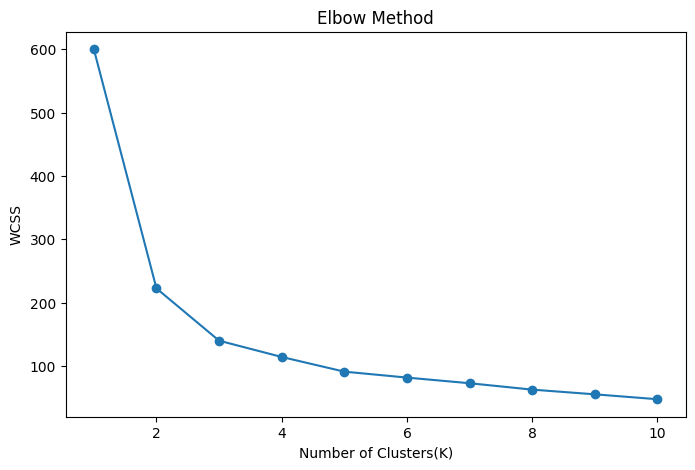

In [13]:
#----------------------------------------
#Step 3: Elbow Method
#----------------------------------------
wcss=[]

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42,n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")
plt.show

In [14]:
#-----------------------------------
#Step 4.Apply K-Means (k=3 for Iris)
#-----------------------------------
kmeans = KMeans(n_clusters=3, random_state=42,n_init=10)
clusters=kmeans.fit_predict(x_scaled)
#Add cluster labels to dataframe
df['Cluster'] = clusters

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_scaled)
df['cluster'] = clusters

In [23]:
#---------------------------------------------------
#Step.5:Silhouette Score
#---------------------------------------------------
score= silhouette_score(x_scaled, clusters)
print("\nSilhouette Score:",score)


Silhouette Score: 0.45994823920518635


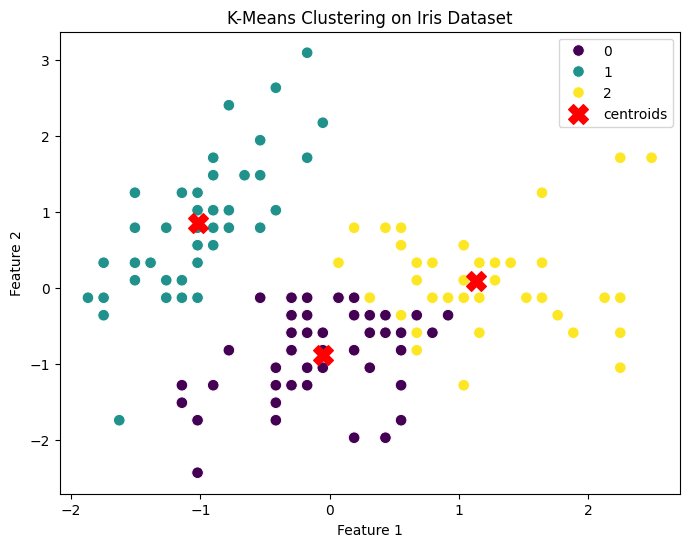

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=x_scaled[:, 0],
    y=x_scaled[:, 1],
    hue=clusters,
    palette="viridis",
    s=70,
)

centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    c="red",
    marker="X",
    label="centroids",
)
plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()